In [6]:
import pandas as pd

In [10]:
df = pd.read_csv("Superstore.csv", encoding='latin1')

In [11]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [12]:
df.shape

(9800, 18)

In [13]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [15]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


In [16]:
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [17]:
df["Sales"].sum()

np.float64(2261536.7827000003)

In [18]:
df.groupby("Region")["Sales"].sum()

,Sales
Region,
Central,492646.9132
East,669518.7260
South,389151.4590
West,710219.6845


In [19]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9800 non-null   int64         
 1   Order_ID       9800 non-null   object        
 2   Order_Date     9800 non-null   datetime64[ns]
 3   Ship_Date      9800 non-null   datetime64[ns]
 4   Ship_Mode      9800 non-null   object        
 5   Customer_ID    9800 non-null   object        
 6   Customer_Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal_Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product_ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub_Category   9800 n

In [21]:
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Furniture,728658.5757
Office Supplies,705422.3340
Technology,827455.8730


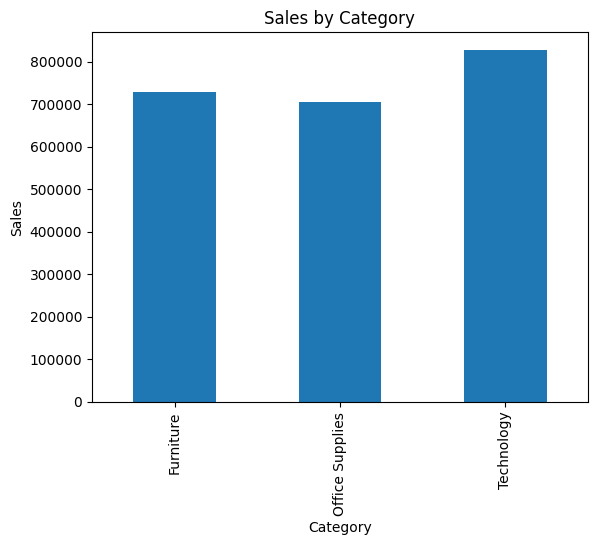

In [24]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

In [25]:
df.groupby('Segment')['Sales'].sum()

,Sales
Segment,
Consumer,1.148061e+06
Corporate,6.884941e+05
Home Office,4.249822e+05


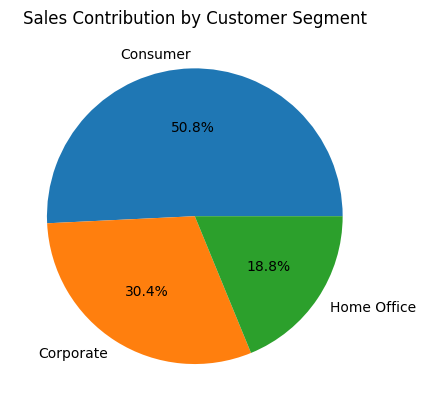

In [26]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title('Sales Contribution by Customer Segment')
plt.ylabel('')
plt.show()

In [27]:
df['Month'] = df['Order_Date'].dt.to_period('M')

In [28]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.head()

,Sales
Month,
2015-01,14205.707
2015-02,4519.892
2015-03,55205.797
2015-04,27906.855
2015-05,23644.303


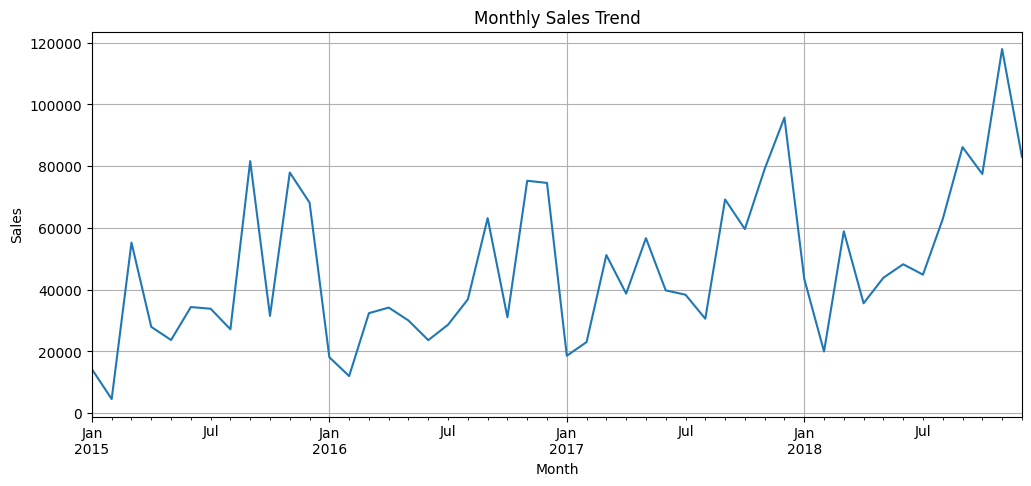

In [29]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(figsize=(12,5))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)

plt.show()

In [30]:
df['Sales'].describe()

,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


In [31]:
df['Sales'].median()

54.489999999999995

In [32]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


In [33]:
df['Sales'].describe()
df['Sales'].median()

54.489999999999995

In [34]:
df['Sales'].mean()

np.float64(230.7690594591837)

In [35]:
df['Sales'].mode()

,Sales
0,12.96


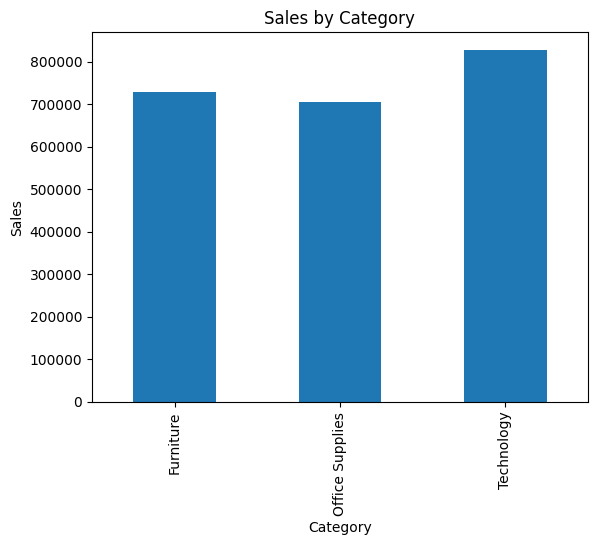

In [41]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

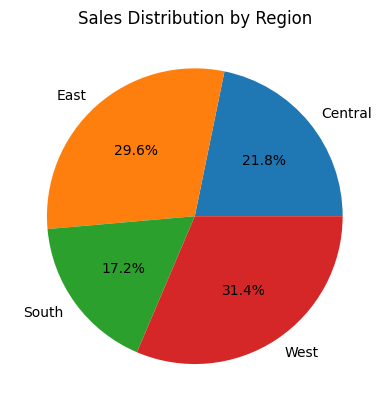

In [42]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sales Distribution by Region")
plt.ylabel("")
plt.show()

In [43]:
df.groupby("Category")["Sales"].sum()

,Sales
Category,
Furniture,728658.5757
Office Supplies,705422.3340
Technology,827455.8730


In [44]:
# Top 10 products by sales

top_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_products)

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [45]:
# Top states

state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

print(state_sales)

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


In [46]:
# Orders per ship mode

df["Ship_Mode"].value_counts()

,count
Ship_Mode,
Standard Class,5859
Second Class,1902
First Class,1501
Same Day,538


In [47]:
# Revenue by region

df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

,Sales
Region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


In [48]:
top_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products

,Sales
Product_Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color,18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [49]:
df['Sales'].median()

54.489999999999995

In [50]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


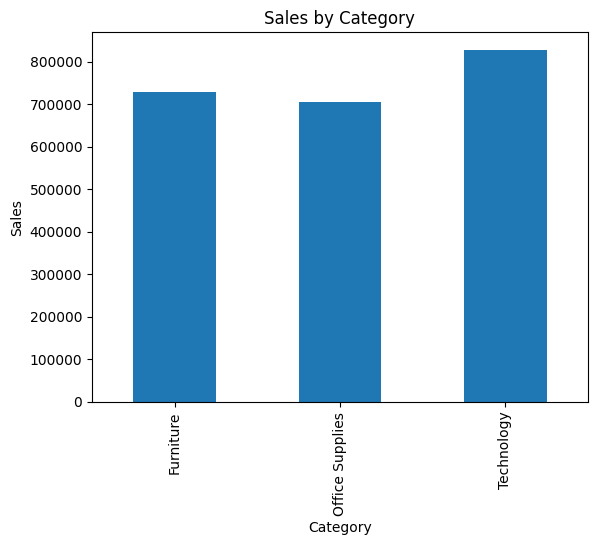

In [51]:
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

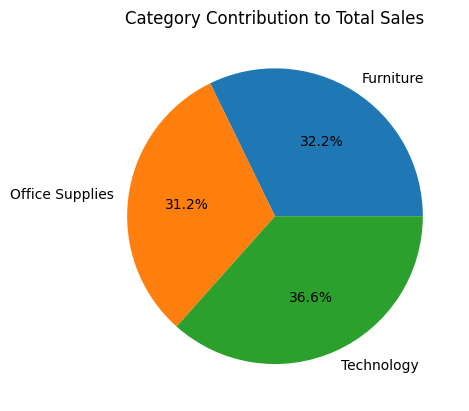

In [52]:
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Category Contribution to Total Sales")
plt.ylabel("")
plt.show()

Key Findings
The Technology category generated the highest sales (approximately $827,456), making it the strongest-performing category.
The West region recorded the highest total sales (approximately $710,220), indicating strong market performance in that region.
The Consumer segment contributed the largest share of revenue (approximately $1.15 million), making it the most valuable customer segment.
Monthly sales trends show fluctuations throughout the year, suggesting seasonal demand patterns.
The product Canon imageCLASS 2200 Advanced Copier generated the highest sales among all products.
Actionable Recommendations for Alfido Tech
Increase investment in Technology products since they generate the highest revenue and demonstrate strong customer demand.
Replicate successful sales strategies from the West region in lower-performing regions to improve overall sales performance.
Develop loyalty and retention programs for Consumer customers, as they contribute the largest portion of total revenue.
Promote top-performing products such as the Canon imageCLASS 2200 Advanced Copier through targeted marketing campaigns and bundled offers.
Improve performance in lower-revenue regions by introducing localized promotions, discounts, and customer engagement initiatives.
Conclusion

The analysis shows that Technology products, Consumer customers, and the West region are the primary drivers of sales performance. By focusing on these strengths while improving weaker regions and categories, Alfido Tech can increase revenue, customer retention, and overall business growth.

### Missing Values

The dataset contains 11 missing values in the Postal_Code column. Since Postal_Code is not critical for sales analysis and only a small number of records are affected, these missing values were retained and did not significantly impact the analysis.